<a href="https://colab.research.google.com/github/cjsnhope/Systems-Biology/blob/main/SB__AS5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Function to draw a population growth curve and a cobweb plot
def Cobweb(r, P0, K, ntime):

    # Simulate the May model
    pop_history = [P0]
    curr_P = P0
    for _ in range(ntime):
        curr_P = curr_P + r * curr_P * (1 - curr_P / K)
        pop_history.append(curr_P)

    # Prepare for plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))
    plt.subplots_adjust(hspace=0.4)


    # --- Plot 1: Growth Curve ---

    ax1.plot(range(ntime + 1), pop_history, color='blue', linewidth=1)

    # Set the labels
    ax1.set_title('The May model', fontweight='bold')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Population')

    # Set the axis limit, ticks
    limit_val = K * 1.4
    ax1.set_ylim(-K * 0.1, limit_val)
    x_ticks = np.arange(0, limit_val + 1, K * 0.2)
    x_labels = [f"{int(t)}" for t in x_ticks]
    y_ticks = np.arange(0, limit_val + 1, K * 0.4)
    y_labels = [f"{int(t)}" for t in y_ticks]

    # Set the legend
    leg_may = plt.Line2D([0], [0], color='blue', linestyle='-', linewidth=1)
    ax1.legend(handles=[leg_may], labels=[f"r: {r}, P0: {float(P0)}, K: {K}"], loc='lower right', bbox_to_anchor=(1, 0),
               borderaxespad=0, fancybox=False, frameon=True, edgecolor='black', borderpad=1)


    # --- Plot 2: Cobweb Plot ---


    # Define the range for the plot
    x = np.linspace(0, limit_val, 500)

    # Growth function: f(P) = P + r*P*(1-P/K)
    y = x + r * x * (1 - x / K)

    ax2.plot(x, y, 'b-', label='May model curve', linewidth=1) # Curve
    ax2.plot([0, limit_val], [0, limit_val], 'k--', linewidth=0.8) # Diagonal line (y=x)

    # Draw trajectory lines (staircase/cobweb)
    curr_P = P0
    for i in range(ntime):
        # f(P_t) = P_t + r*P_t*(1-P_t/K)
        next_P = curr_P + r * curr_P * (1 - curr_P / K)

        # Vertical line from (P_t, P_t) to (P_t, P_t+1)
        ax2.plot([curr_P, curr_P], [curr_P, next_P], 'k-', linewidth=0.5)
        # Horizontal line from (P_t, P_t+1) to (P_t+1, P_t+1)
        ax2.plot([curr_P, next_P], [next_P, next_P], 'k-', linewidth=0.5)

        curr_P = next_P

    # Set the labels
    ax2.set_title('Cobweb plot of the model above', fontweight='bold')
    ax2.set_xlabel(r'$\mathrm{P_t}$')
    ax2.set_ylabel(r'$\mathrm{P_{t+1}}$')

    # Set the ticks
    y_ticks = np.arange(0, limit_val + 1, K * 0.2)
    y_labels = [f"{int(t)}" if t % (K * 0.4) == 0 else "" for t in y_ticks]
    ax2.set_yticks(y_ticks)
    ax2.set_yticklabels(y_labels, va='center', rotation=90)
    ax2.set_xticks(y_ticks)
    ax2.set_xticklabels([f"{int(t)}" for t in y_ticks])

    # Set the axis ranges
    ax2.set_xlim(-limit_val * 0.05, limit_val + limit_val * 0.05)
    ax2.set_ylim(-limit_val * 0.05, limit_val + limit_val * 0.05)

    plt.show()

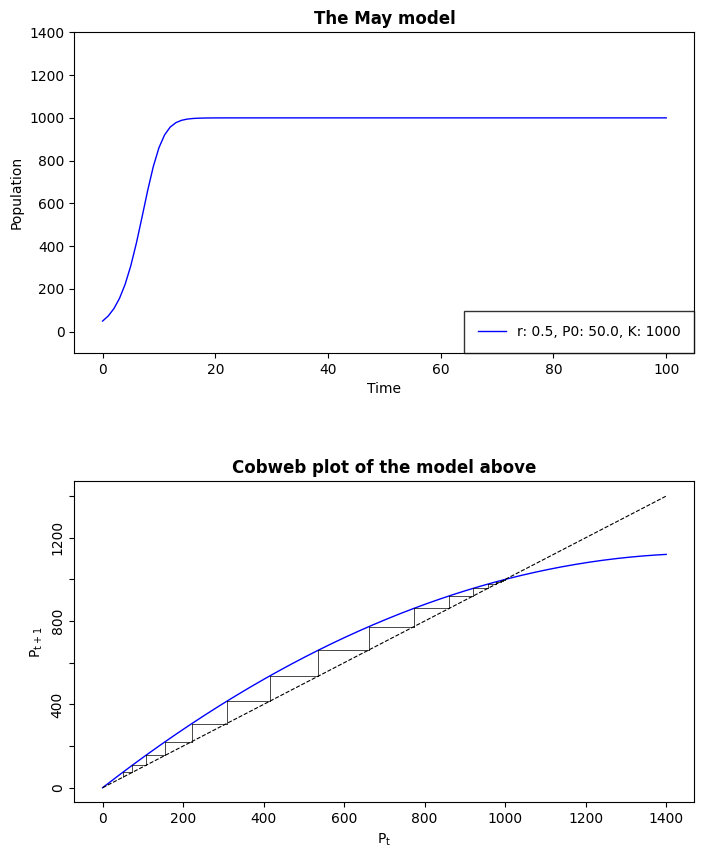

In [31]:
### Simulation 1 ###
# r=0.5
Cobweb(r=0.5, P0=50, K=1000, ntime=100)

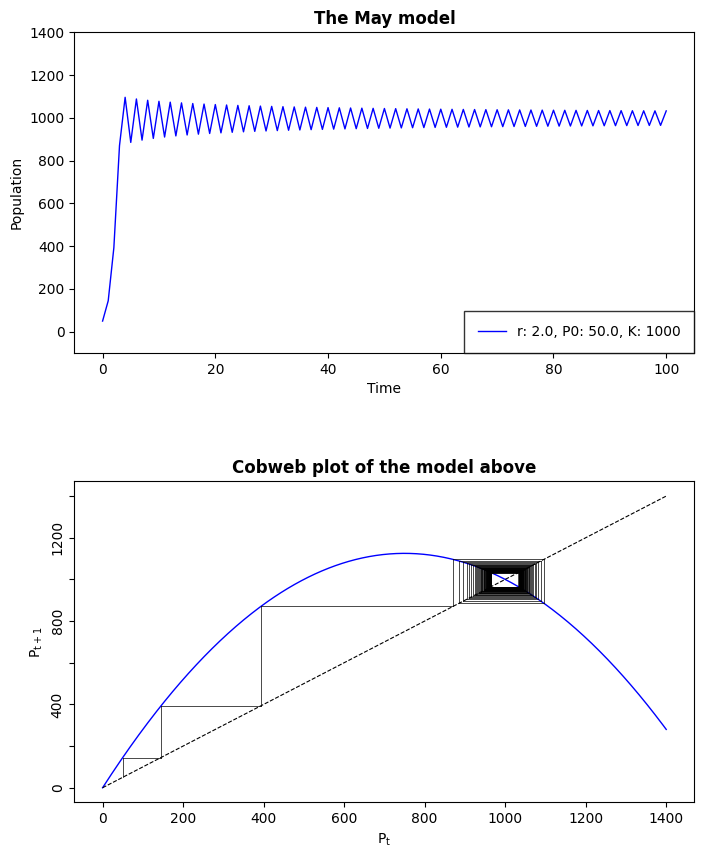

In [32]:
### Simulation 2 ###
# r=2
Cobweb(r=2.0, P0=50, K=1000, ntime=100)

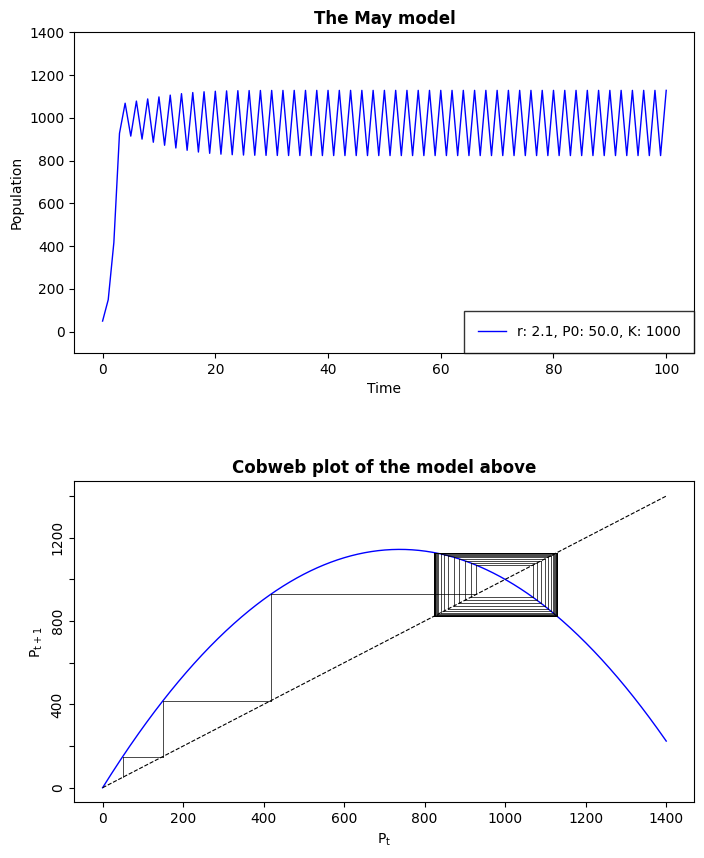

In [33]:
### Simulation 3 ###
# r=2.1
Cobweb(r=2.1, P0=50, K=1000, ntime=100)

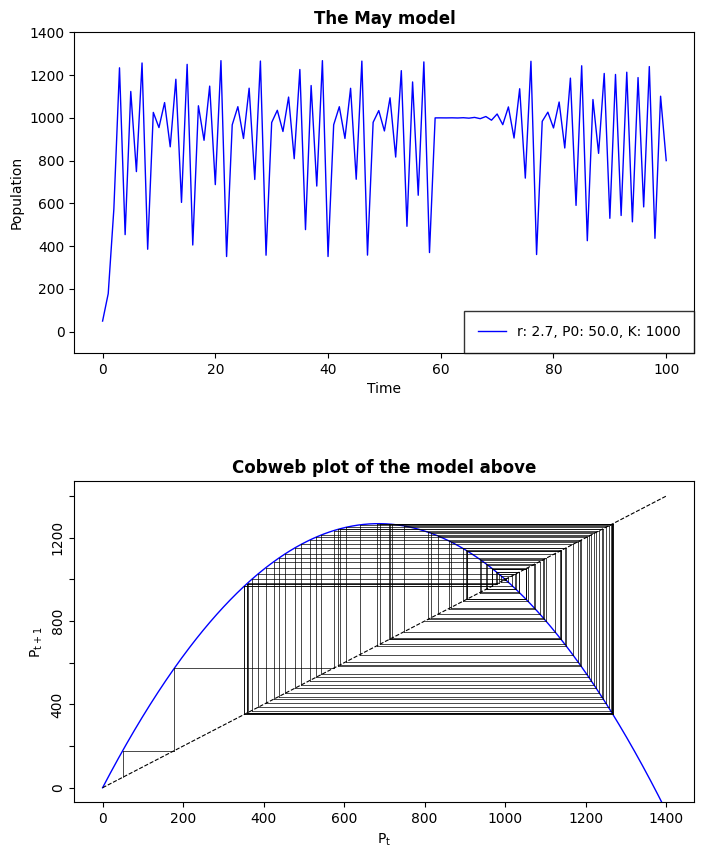

In [34]:
### Simulation 4 ###
# r=2.7
Cobweb(r=2.7, P0=50, K=1000, ntime=100)

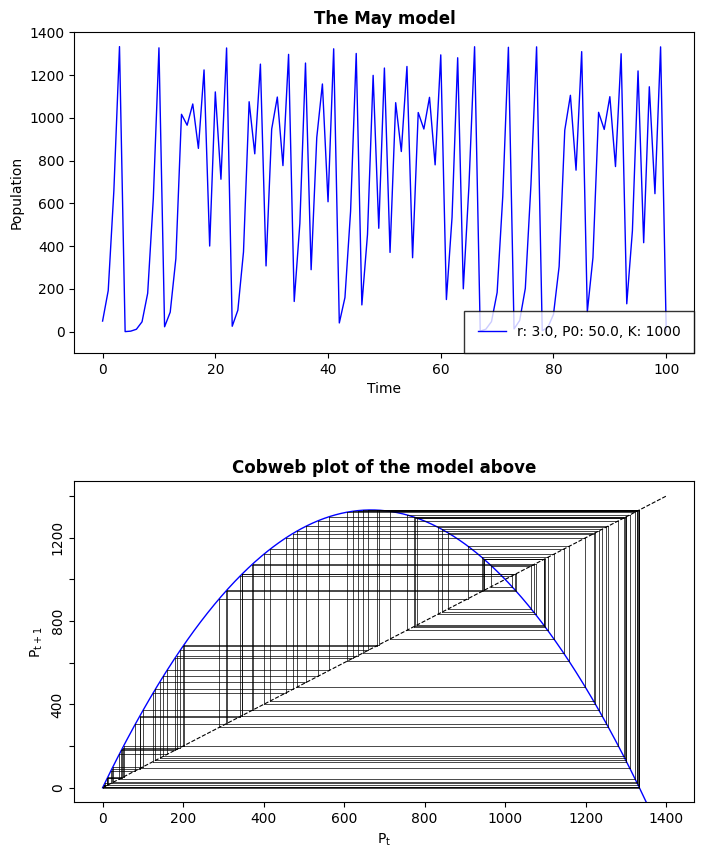

In [35]:
### Simulation 5 ###
# r=3
Cobweb(r=3.0, P0=50, K=1000, ntime=100)

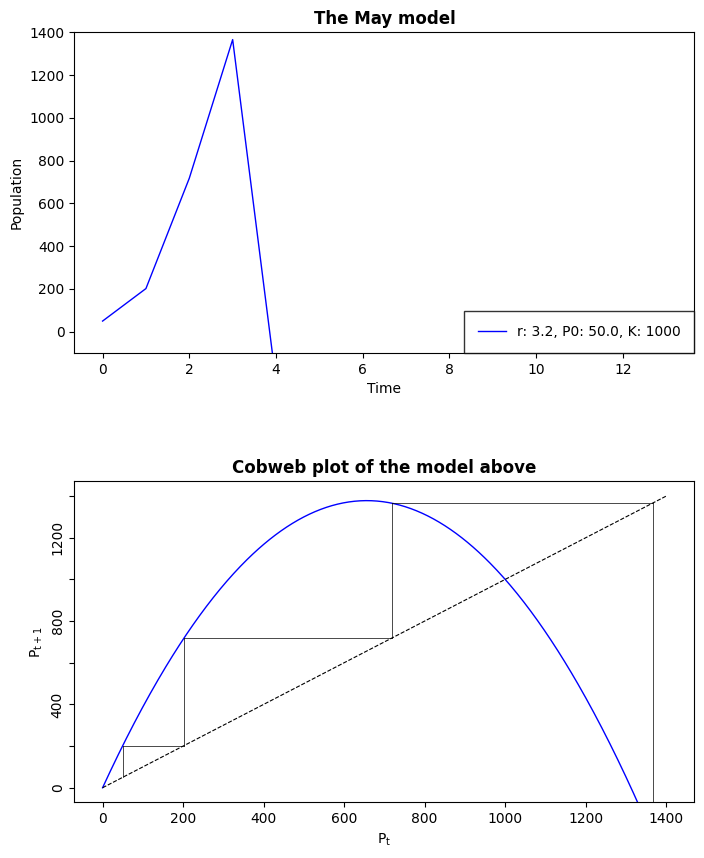

In [36]:
### Simulation 6 ###
# r=3.2
Cobweb(r=3.2, P0=50, K=1000, ntime=100)

/tmp/ipykernel_26454/3302218912.py:13: RuntimeWarning: overflow encountered in scalar multiply
  P = P + r * P * (1 - P / K)


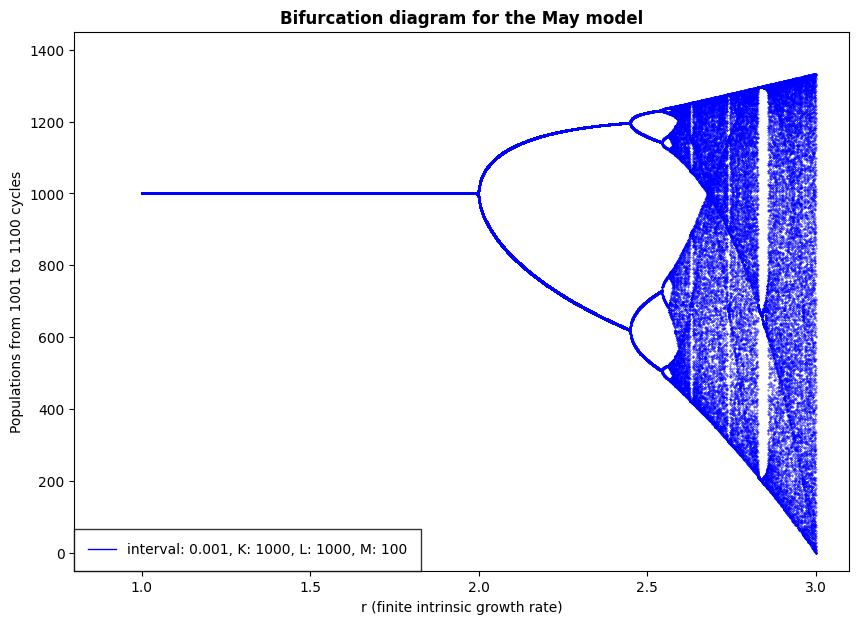

In [42]:
def bifurcation(r_range, interval, K, L, M):

    r_values = np.arange(r_range[0], r_range[1], interval)

    plt.figure(figsize=(10, 7))

    for r in r_values:
        # Random initial population
        P = np.random.uniform(0, K * 0.1)

        # Iterate L times to discard transient behavior
        for _ in range(L):
            P = P + r * P * (1 - P / K)

        # Iterate M times and plot the results
        m_results = []
        for _ in range(M):
            P = P + r * P * (1 - P / K)
            m_results.append(P)

        # Plot all M points for this r value
        # Using small marker size (s) and alpha for better visualization
        plt.scatter([r] * M, m_results, s=0.1, color='blue', marker='o')

    # Set the titles
    plt.title("Bifurcation diagram for the May model", fontweight='bold')
    plt.xlabel("r (finite intrinsic growth rate)")
    plt.ylabel(f"Populations from {L+1} to {L+M} cycles")

    # Set the axis range, ticks
    plt.ylim( - K * 0.05, K * 1.4 + K * 0.05)
    plt.xlim(r_range[0] - 0.2, r_range[1])
    plt.xticks(np.arange(1.0, 3.1, 0.5))

    # Create the line in the legend
    from matplotlib.lines import Line2D
    custom_line = [Line2D([0], [0], color='blue', lw=1)]

    # Set the legend
    plt.legend(handles=custom_line, labels=[f"interval: {interval}, K: {K}, L: {L}, M: {M}"], loc='lower left',
               bbox_to_anchor=(0, 0), borderaxespad=0, edgecolor='black', fancybox=False, frameon=True, borderpad=1)

    plt.legend

    plt.show()


# Run bifurcation diagram with assignment parameters
bifurcation(r_range=(1, 3.1), interval=0.001, K=1000, L=1000, M=100)